# Exercise 2 — Classification Metrics

## Part A: Understanding Model Evaluation

In classification problems, accuracy alone is not always enough.

A model may appear “good” while still making important mistakes.

In this exercise, we will learn how to evaluate classification models using:

* accuracy
* precision
* recall
* F1-score
* confusion matrix

### Example Problem

Imagine we are building a spam detector.

The model predicts:

`1 = spam`

`0 = not spam`

### Step 1 — Real Labels vs Predictions

In [5]:
import numpy as np

# True labels
y_true = np.array([
    1,1,1,1,1,
    0,0,0,0,0
])

# Model predictions
y_pred = np.array([
    1,1,1,0,1,
    0,0,1,1,1
])

### Step 2 — Compute the Confusion Matrix

In [6]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[2 3]
 [1 4]]


### Understanding the Confusion Matrix

Where:

* TP = true positives
* TN = true negatives
* FP = false positives
* FN = false negatives

### Visualize the Confusion Matrix

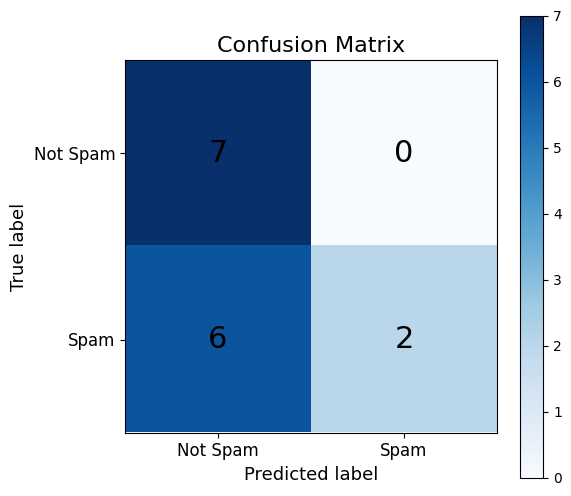

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,6))

plt.imshow(cm, cmap="Blues")

# Axis labels
classes = ["Not Spam", "Spam"]

plt.xticks([0,1], classes, fontsize=12)
plt.yticks([0,1], classes, fontsize=12)

# Numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=22,
            color="black"
        )

# Labels
plt.xlabel("Predicted label", fontsize=13)
plt.ylabel("True label", fontsize=13)

plt.title("Confusion Matrix", fontsize=16)

plt.colorbar()

plt.show()

### Step 3 — Compute Metrics

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1-score : {f1:.2f}")

Accuracy : 0.60
Precision: 0.57
Recall   : 0.80
F1-score : 0.67


### What Do These Metrics Mean?

#### Accuracy
How many predictions were correct overall?

#### Precision
When the model predicts SPAM,
how often is it correct?

#### Recall
How many real spam messages did the model find?

#### F1-score
Balance between precision and recall


Questions

1. Is accuracy always enough?  
- NO. Accuracy only tells what fraction of predictions were correct overall, but it also hides mistakes were made. A model can have high accuracy while being useless (or dangerous) in real life.
  
2. What happens if classes are imbalanced?
- Then the accuracy will become misleading. If the percentage of spam email larger than ham email (like 99% - 1%), then the model that predict a situation with many spam will have a high accuracy, but when it predict the ham sitation (like 99% ham), it cannot predict, which means not useful and a failure. 

3. Why might high accuracy still be misleading?
- Accuracy only tell about the percentage of predictions are correct, and it tells nothing about the mistakes

4. In medical diagnosis, which is worse:
    * false positive?
    * false negative?
- I think it's false negative, because for some health problem, a patient who have health problem might be predicted as healthy

5. Which metric would matter most for:
    * spam filtering?
- FOR SPAM FILTERING: (high) precision (we don't want to get the ham emails as predicted as spam and vice versa.)

    * fraud detection?
- FOR FRAUD DETECTION: (high) recall (We want detect the fraud as much as possibile)
  
    * disease detection?
- FOR DISEASE DETECTION: (high) recall (We want to recognize as much sick patients as possibile)

## Part B — Try Your Own Predictions

Modify: `y_pred`

Then rerun the notebook and observe:

* how the confusion matrix changes
* how the metrics change
* which mistakes increase or decrease

## Bonus Challenge

Create:

1. a model with:
    * high precision
    * low recall
2. a model with:
    * high recall
    * low precision

Explain the difference.

## MODEL 1 - High precision and low recall

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

In [26]:
# predict only two 1, but all are correct

y_true = np.array([
    1, 1, 1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0])

y_pred = np.array([
    1, 1, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0])

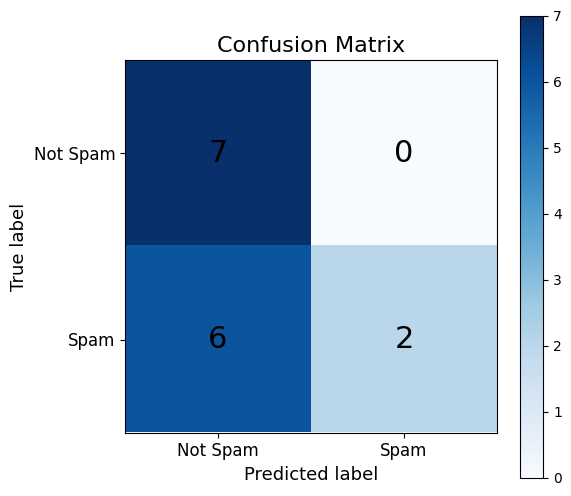

In [27]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,6))

plt.imshow(cm, cmap="Blues")

# Axis labels
classes = ["Not Spam", "Spam"]

plt.xticks([0,1], classes, fontsize=12)
plt.yticks([0,1], classes, fontsize=12)

# Numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=22,
            color="black"
        )

# Labels
plt.xlabel("Predicted label", fontsize=13)
plt.ylabel("True label", fontsize=13)

plt.title("Confusion Matrix", fontsize=16)

plt.colorbar()

plt.show()

In [28]:
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")

Precision: 1.00
Recall   : 0.25


## MODEL 2 - High recall and low precision

In [29]:
#over-predicts 1s constantly
y_true = np.array([
    1, 1, 1, 0, 0,
    0, 0, 0, 0, 0,
    0, 0, 0, 0, 0])

y_pred = np.array([
    1, 1, 1, 1, 1,
    1, 1, 1, 1, 1,
    1, 1, 0, 0, 0])

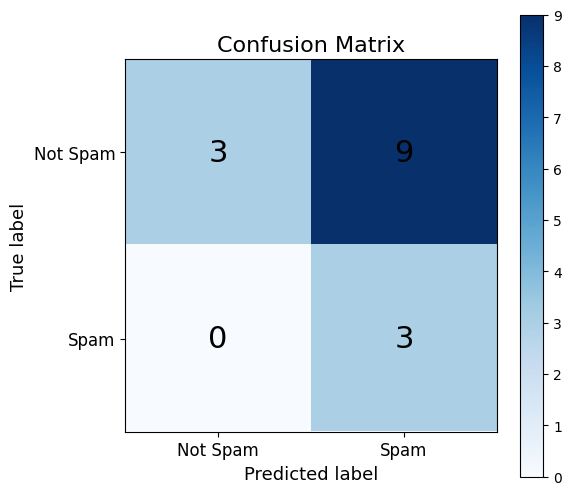

In [30]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,6))

plt.imshow(cm, cmap="Blues")

# Axis labels
classes = ["Not Spam", "Spam"]

plt.xticks([0,1], classes, fontsize=12)
plt.yticks([0,1], classes, fontsize=12)

# Numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=22,
            color="black"
        )

# Labels
plt.xlabel("Predicted label", fontsize=13)
plt.ylabel("True label", fontsize=13)

plt.title("Confusion Matrix", fontsize=16)

plt.colorbar()

plt.show()

In [31]:
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")

Precision: 0.25
Recall   : 1.00


### High Precision - Low Recall:
- minimize false positives
- rarely flags an item, but when it does, it always correct. But it misses a lot of valid targe
---> Apply for spam filter. It misses some spam (low recall) but never put important work email to junk (high precision)
  
### High Recall - Low Precision
- minimize false negative
- it ensures it capture every single valid target which means got incorrect item
---> Apply for cancer detection. It marks many healthy tissues as suspicious (low precision) but ensures that almost no actual tumors go undetected (high recall).